# 📊 Telco Customer Churn Prediction — Improved Version
**Improvements:** OneHotEncoding · Class Imbalance Handling · Multiple Models · ROC-AUC · Feature Engineering · SHAP · Cross-Validation

## 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score, accuracy_score)

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Class Imbalance
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
except ImportError:
    print('imbalanced-learn not installed. Run: pip install imbalanced-learn')
    SMOTE_AVAILABLE = False

# XGBoost / LightGBM
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    print('XGBoost not installed. Run: pip install xgboost')
    XGB_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except ImportError:
    print('LightGBM not installed. Run: pip install lightgbm')
    LGBM_AVAILABLE = False

# SHAP
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    print('SHAP not installed. Run: pip install shap')
    SHAP_AVAILABLE = False

import joblib
print('✅ All libraries loaded!')

✅ All libraries loaded!


## 2️⃣ Load & Explore Data

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Basic info
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
Payment

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.5%


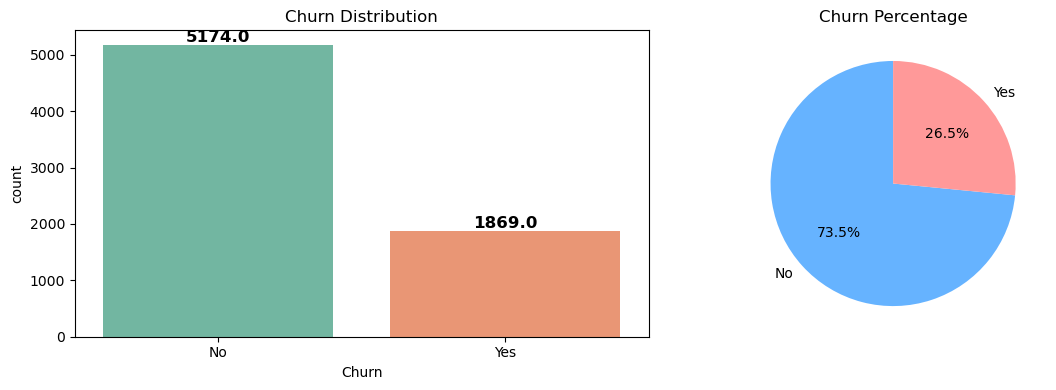

In [4]:
# Class distribution — check imbalance
churn_counts = df['Churn'].value_counts()
print('Churn Distribution:')
print(churn_counts)
print(f'\nChurn Rate: {churn_counts["Yes"] / len(df) * 100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='Churn', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Churn Distribution')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#66b3ff','#ff9999'], startangle=90)
axes[1].set_title('Churn Percentage')

plt.tight_layout()
plt.show()

## 3️⃣ Data Preprocessing

In [5]:
# Drop customerID (not useful for prediction)
df = df.drop(columns=['customerID'])

# Fix TotalCharges — has spaces as strings
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'NaN in TotalCharges: {df["TotalCharges"].isnull().sum()}')

# Fill NaN with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode target variable
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print('✅ Basic cleaning done!')

NaN in TotalCharges: 11
✅ Basic cleaning done!


## 4️⃣ Feature Engineering 🆕
> Creating new features to give the model better signals

In [6]:
# Feature 1: Average monthly charges over tenure
df['AvgMonthlyCharge'] = df['TotalCharges'] / (df['tenure'] + 1)

# Feature 2: Count of add-on services subscribed
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']
df['ServiceCount'] = df[addon_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)

# Feature 3: Is new customer? (tenure <= 6 months)
df['IsNewCustomer'] = (df['tenure'] <= 6).astype(int)

# Feature 4: Is long-term customer? (tenure > 24 months)
df['IsLongTermCustomer'] = (df['tenure'] > 24).astype(int)

# Feature 5: High charges flag
df['HighCharges'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

print('New features created:')
print(df[['AvgMonthlyCharge', 'ServiceCount', 'IsNewCustomer', 'IsLongTermCustomer', 'HighCharges']].head())

New features created:
   AvgMonthlyCharge  ServiceCount  IsNewCustomer  IsLongTermCustomer  \
0         14.925000             1              1                   0   
1         53.985714             2              0                   1   
2         36.050000             2              1                   0   
3         40.016304             3              0                   1   
4         50.550000             0              1                   0   

   HighCharges  
0            0  
1            0  
2            0  
3            0  
4            1  


## 5️⃣ Smart Encoding (OneHotEncoder for Nominal Columns) 🆕
> ⚠️ LabelEncoder assigns numbers like 0,1,2 which creates fake ordering. OneHotEncoder is correct for nominal categories.

In [7]:
# Separate column types
# Binary columns (only 2 values) — safe to label encode
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines']

# Multi-class nominal columns — use OneHotEncoder
ohe_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies', 'Contract', 'PaymentMethod']

# Numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
            'AvgMonthlyCharge', 'ServiceCount', 'IsNewCustomer',
            'IsLongTermCustomer', 'HighCharges']

# Label encode binary columns
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

print('Binary columns label-encoded.')

# Prepare X and y
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

Binary columns label-encoded.
X shape: (7043, 24)
y shape: (7043,)


In [8]:
# Train/test split (stratified to preserve churn ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Train churn rate: {y_train.mean():.2%}')
print(f'Test churn rate:  {y_test.mean():.2%}')

Train size: 5634 | Test size: 1409
Train churn rate: 26.54%
Test churn rate:  26.54%


In [9]:
# Build preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols + binary_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), ohe_cols)
])

print('✅ Preprocessor ready!')

✅ Preprocessor ready!


## 6️⃣ Train Multiple Models 🆕

In [10]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'Neural Network':      MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42),
}

if XGB_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, use_label_encoder=False,
        eval_metric='logloss', scale_pos_weight=3, random_state=42
    )

if LGBM_AVAILABLE:
    models['LightGBM'] = LGBMClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, verbose=-1
    )

print(f'Models to train: {list(models.keys())}')

Models to train: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'Neural Network', 'XGBoost', 'LightGBM']


In [11]:
# Train and evaluate all models
results = []
trained_models = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
    trained_models[name] = pipe
    print(f'✅ {name} done — AUC: {roc_auc_score(y_test, y_proba):.4f}')

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print('\n📊 Model Comparison:')
results_df.style.highlight_max(axis=0, color='lightgreen')

✅ Logistic Regression done — AUC: 0.8469
✅ Random Forest done — AUC: 0.8232
✅ Gradient Boosting done — AUC: 0.8395
✅ Neural Network done — AUC: 0.7809
✅ XGBoost done — AUC: 0.8126
✅ LightGBM done — AUC: 0.8321

📊 Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.743790,0.511149,0.796791,0.622780,0.846924
1,Gradient Boosting,0.795600,0.649306,0.500000,0.564955,0.839460
2,LightGBM,0.770759,0.552147,0.721925,0.625724,0.832115
3,Random Forest,0.786373,0.629893,0.473262,0.540458,0.823165
4,XGBoost,0.770050,0.560096,0.622995,0.589873,0.812616
5,Neural Network,0.757984,0.547278,0.510695,0.528354,0.780898


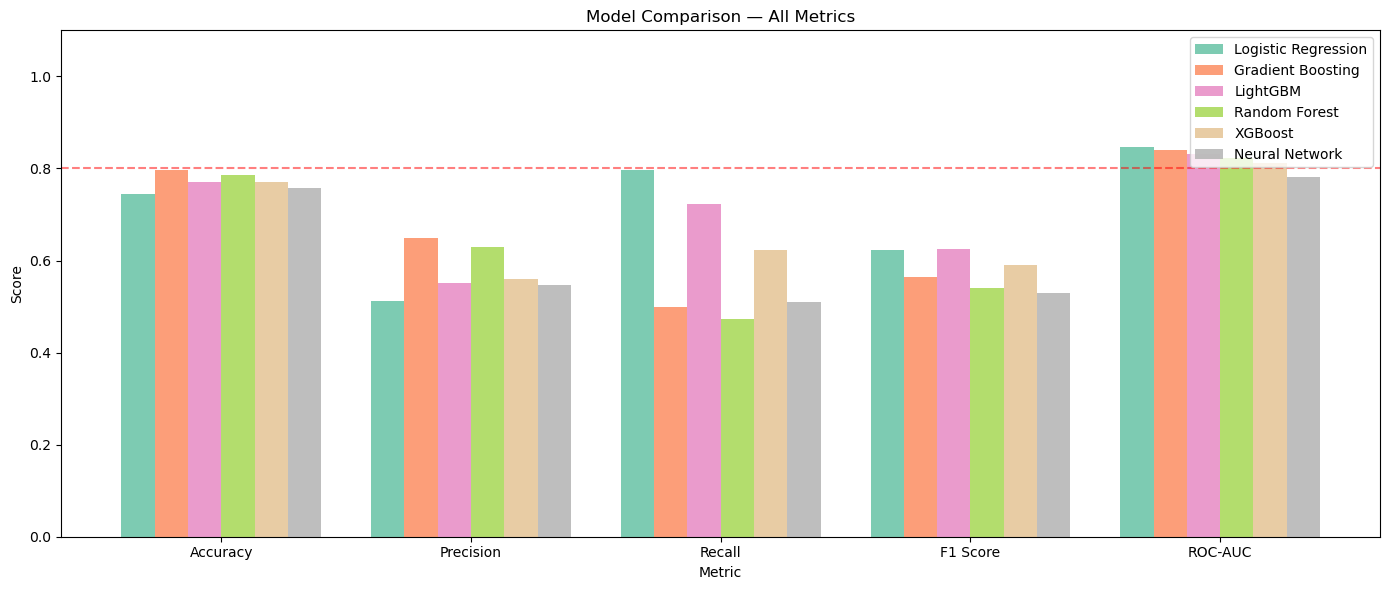

In [12]:
# Visualize model comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.8 / len(results_df)

fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.cm.Set2(np.linspace(0, 1, len(results_df)))
for i, (_, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    offset = (i - len(results_df)/2) * width + width/2
    bars = ax.bar(x + offset, vals, width, label=row['Model'], color=colors[i], alpha=0.85)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper right')
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='0.8 threshold')
plt.tight_layout()
plt.show()

## 7️⃣ ROC Curves 🆕

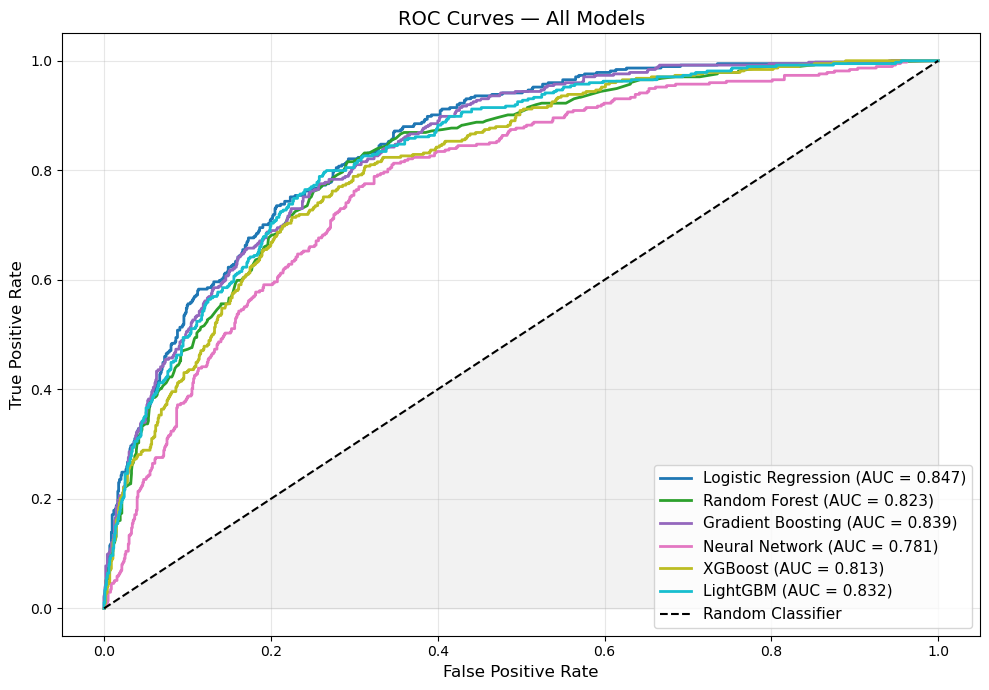

In [13]:
plt.figure(figsize=(10, 7))

colors = plt.cm.tab10(np.linspace(0, 1, len(trained_models)))

for (name, pipe), color in zip(trained_models.items(), colors):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)
plt.fill_between([0, 1], [0, 1], alpha=0.1, color='gray')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8️⃣ Cross-Validation (Best Model) 🆕

Best model: Logistic Regression

5-Fold CV ROC-AUC Scores: [0.86093286 0.84775375 0.85970446 0.83169367 0.83961486]
Mean AUC: 0.8479 ± 0.0113


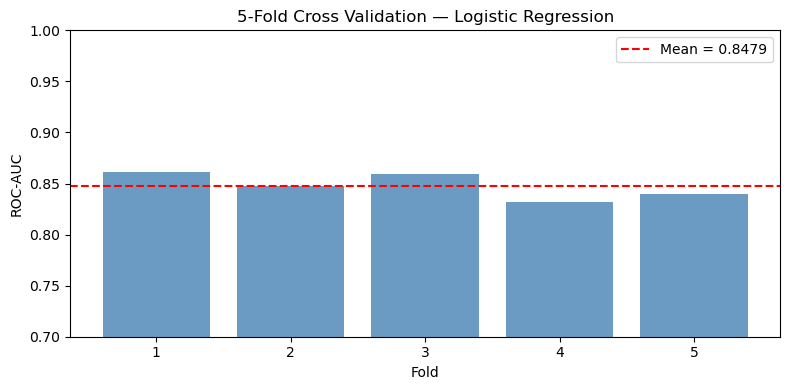

In [14]:
# Get best model name
best_model_name = results_df.iloc[0]['Model']
best_pipe = trained_models[best_model_name]
print(f'Best model: {best_model_name}')

# 5-Fold Stratified Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_pipe, X, y, cv=cv, scoring='roc_auc')

print(f'\n5-Fold CV ROC-AUC Scores: {cv_scores}')
print(f'Mean AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Plot CV results
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.8)
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('ROC-AUC')
plt.title(f'5-Fold Cross Validation — {best_model_name}')
plt.legend()
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()

## 9️⃣ Confusion Matrix (Best Model)

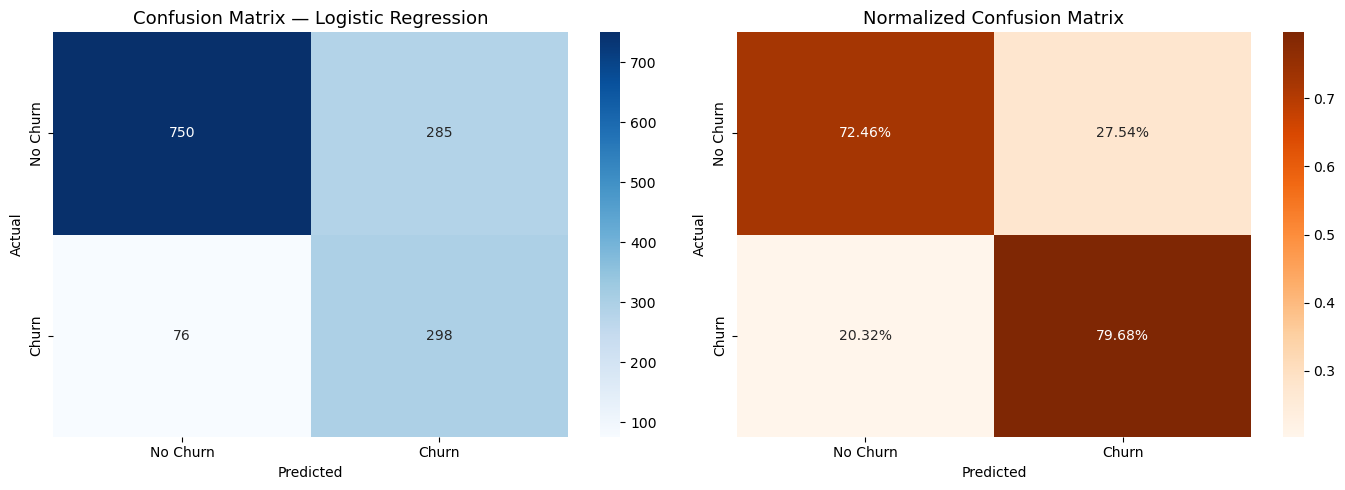


Detailed Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.81      1035
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [15]:
y_pred_best = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title(f'Confusion Matrix — {best_model_name}', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges', ax=axes[1],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[1].set_title('Normalized Confusion Matrix', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

## 🔟 Hyperparameter Tuning (Random Forest) 🆕

In [16]:
# Tune Random Forest as example (can apply to any model)
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 5, 10, 15],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__class_weight': ['balanced', None]
}

rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

search = RandomizedSearchCV(
    rf_pipe, param_grid, n_iter=20,
    cv=StratifiedKFold(n_splits=5),
    scoring='roc_auc', n_jobs=-1, random_state=42, verbose=1
)

search.fit(X_train, y_train)

print(f'Best AUC (CV): {search.best_score_:.4f}')
print(f'Best Params: {search.best_params_}')

# Evaluate tuned model
y_pred_tuned = search.best_estimator_.predict(X_test)
y_proba_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
print(f'\nTuned RF Test AUC: {roc_auc_score(y_test, y_proba_tuned):.4f}')
print(f'Tuned RF F1:      {f1_score(y_test, y_pred_tuned):.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best AUC (CV): 0.8436
Best Params: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 10, 'classifier__class_weight': 'balanced'}

Tuned RF Test AUC: 0.8429
Tuned RF F1:      0.6302


## 1️⃣1️⃣ SHAP Explainability 🆕
> Understand WHY the model predicts churn for each customer

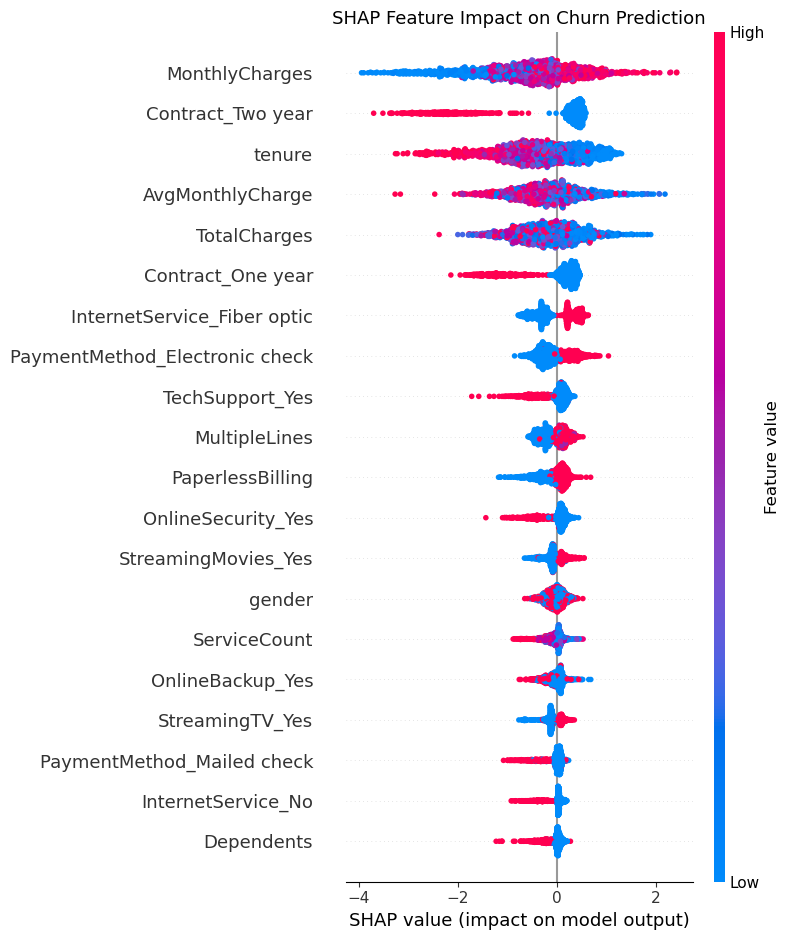

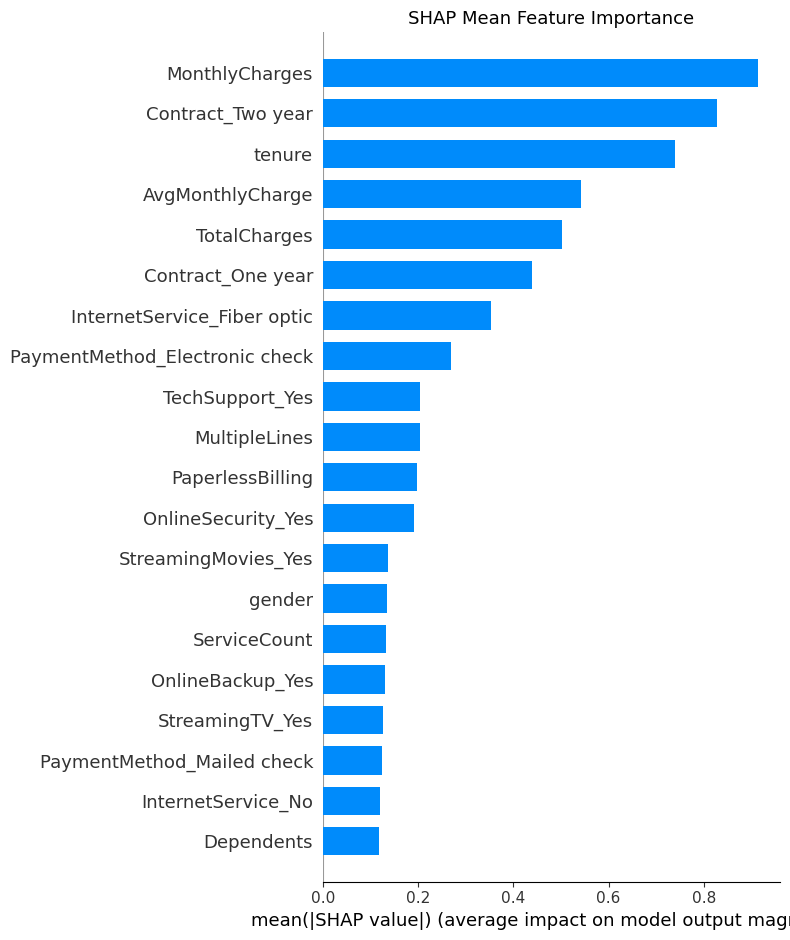

In [17]:
if SHAP_AVAILABLE:
    # Get the best tree-based model for SHAP
    # Try XGBoost first, else Random Forest
    shap_model_name = 'XGBoost' if XGB_AVAILABLE else 'Random Forest'
    shap_pipe = trained_models.get(shap_model_name, trained_models['Random Forest'])
    
    # Transform test data through preprocessor
    X_test_transformed = shap_pipe.named_steps['preprocessor'].transform(X_test)
    
    # Get feature names after OHE
    ohe_feature_names = shap_pipe.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(ohe_cols)
    num_binary_names = num_cols + binary_cols
    all_feature_names = num_binary_names + list(ohe_feature_names)
    
    # SHAP explainer
    explainer = shap.TreeExplainer(shap_pipe.named_steps['classifier'])
    shap_values = explainer.shap_values(X_test_transformed)
    
    # If output is list (RF binary), take churn class
    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values

    # Summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X_test_transformed, feature_names=all_feature_names, show=False)
    plt.title('SHAP Feature Impact on Churn Prediction', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Bar plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv, X_test_transformed, feature_names=all_feature_names,
                      plot_type='bar', show=False)
    plt.title('SHAP Mean Feature Importance', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('SHAP not available. Run: pip install shap')

## 1️⃣2️⃣ Single Customer Churn Prediction 🔮

🔮 Single Customer Churn Prediction
Churn Probability : 11.84%
Prediction        : ✅ WILL NOT CHURN
Actual            : Not Churned
Risk Category     : 🟢 LOW RISK


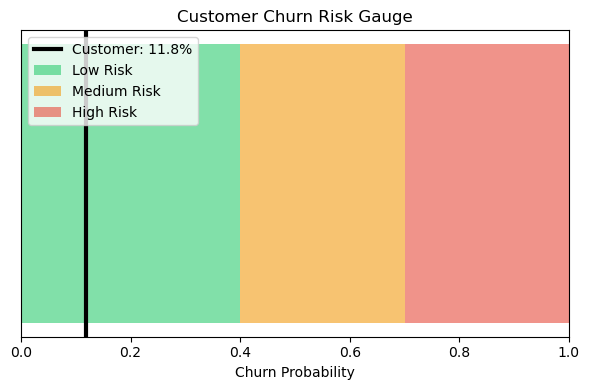

In [18]:
# Predict churn for a new customer
sample_customer = X_test.iloc[[0]].copy()

churn_prob = best_pipe.predict_proba(sample_customer)[0][1]
churn_pred = best_pipe.predict(sample_customer)[0]

print('=' * 50)
print('🔮 Single Customer Churn Prediction')
print('=' * 50)
print(f'Churn Probability : {churn_prob:.2%}')
print(f'Prediction        : {"⚠️ WILL CHURN" if churn_pred == 1 else "✅ WILL NOT CHURN"}')
print(f'Actual            : {"Churned" if y_test.iloc[0] == 1 else "Not Churned"}')

# Risk category
if churn_prob >= 0.7:
    risk = '🔴 HIGH RISK'
elif churn_prob >= 0.4:
    risk = '🟡 MEDIUM RISK'
else:
    risk = '🟢 LOW RISK'
print(f'Risk Category     : {risk}')

# Gauge chart
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
thresholds = [0, 0.4, 0.7, 1.0]
labels = ['Low Risk', 'Medium Risk', 'High Risk']

for i, (label, color) in enumerate(zip(labels, colors)):
    ax.barh(0, thresholds[i+1] - thresholds[i], left=thresholds[i],
            height=0.5, color=color, alpha=0.6, label=label)

ax.axvline(x=churn_prob, color='black', linewidth=3, label=f'Customer: {churn_prob:.1%}')
ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xlabel('Churn Probability')
ax.set_title('Customer Churn Risk Gauge')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 1️⃣3️⃣ Bulk Prediction — High Risk Customers 🆕

In [19]:
# Get churn probabilities for all test customers
proba_all = best_pipe.predict_proba(X_test)[:, 1]

risk_df = X_test.copy()
risk_df['ChurnProbability'] = proba_all
risk_df['ActualChurn'] = y_test.values
risk_df['RiskLevel'] = pd.cut(proba_all,
                               bins=[0, 0.4, 0.7, 1.0],
                               labels=['Low', 'Medium', 'High'])

# Top 10 highest risk customers
print('🔴 Top 10 Highest Churn Risk Customers:')
top_risk = risk_df.sort_values('ChurnProbability', ascending=False).head(10)
print(top_risk[['tenure', 'MonthlyCharges', 'TotalCharges', 'ChurnProbability', 'ActualChurn', 'RiskLevel']])

# Risk distribution
risk_counts = risk_df['RiskLevel'].value_counts()
print(f'\nRisk Distribution:')
print(risk_counts)

🔴 Top 10 Highest Churn Risk Customers:
      tenure  MonthlyCharges  TotalCharges  ChurnProbability  ActualChurn  \
3380       1           95.10         95.10          0.977446            1   
6866       1           95.45         95.45          0.972299            1   
4585       1           85.05         85.05          0.964770            1   
2397       1           88.35         88.35          0.961571            1   
642        1           89.55         89.55          0.960813            1   
2246       1          102.45        102.45          0.958699            1   
6894       3          105.90        334.65          0.952313            1   
6748       1           85.00         85.00          0.951775            1   
2519       2           91.45        171.45          0.951059            0   
3727       3           96.60        291.90          0.949204            1   

     RiskLevel  
3380      High  
6866      High  
4585      High  
2397      High  
642       High  
2246      H

## 1️⃣4️⃣ Save Best Model

In [20]:
# Save the best pipeline (includes preprocessor + model)
joblib.dump(best_pipe, 'churn_model_improved.pkl')

# Save results
results_df.to_csv('model_comparison.csv', index=False)

print(f'✅ Best model saved: churn_model_improved.pkl')
print(f'✅ Results saved: model_comparison.csv')
print(f'\n🏆 Best Model: {best_model_name}')
print(f'   ROC-AUC: {results_df.iloc[0]["ROC-AUC"]:.4f}')
print(f'   F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')

# Load and verify
loaded_model = joblib.load('churn_model_improved.pkl')
test_pred = loaded_model.predict(X_test.head(3))
print(f'\n✅ Model loaded and verified. Sample predictions: {test_pred}')

✅ Best model saved: churn_model_improved.pkl
✅ Results saved: model_comparison.csv

🏆 Best Model: Logistic Regression
   ROC-AUC: 0.8469
   F1 Score: 0.6228

✅ Model loaded and verified. Sample predictions: [0 1 0]


## 📋 Summary of Improvements

| Feature | Old Version | New Version |
|---|---|---|
| Encoding | LabelEncoder (wrong) | OneHotEncoder + LabelEncoder (correct) |
| Class Imbalance | Not handled | `class_weight='balanced'` |
| Models | Random Forest only | RF + LR + GBM + NN + XGBoost + LightGBM |
| Metrics | Accuracy only | Accuracy + Precision + Recall + F1 + ROC-AUC |
| Validation | Single split | 5-Fold Stratified CV |
| Tuning | None | RandomizedSearchCV |
| Features | Raw only | +5 engineered features |
| Explainability | Feature importance | SHAP values |
| Pipeline | Manual scaler | sklearn Pipeline (no data leakage) |
| Risk Scoring | Binary prediction | Probability + Risk level |
